# Random Forest with Cross-Validation (70/30 Subject Split)

- 70% of subjects → training pool (with 5-fold cross-validation for tuning)
- 30% of subjects → held-out test set (never seen during training or tuning)
- Prediction is per-recording; subject-level = majority vote across recordings

---

In [1]:
CYMO_CSV   = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_CSV   = './cymo_parkceleb_per_recording_metadata.csv'
FEAT_CSV   = './mrmr_top10_features.csv'

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib, warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, f1_score, recall_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, auc)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.titleweight': 'bold'})
print('OK')

OK


In [3]:
# Load & merge
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)
features = pd.read_csv(FEAT_CSV)['feature'].tolist()

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]

df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)

for col in features:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        df[col] = 0.0
        print(f'  WARNING: feature "{col}" not found, filled with 0')

features = [f for f in features if f in df.columns]
df[features] = df[features].fillna(df[features].median())

print(f'{len(df)} recordings, {df["subject"].nunique()} subjects, {len(features)} features')
print(f'CN: {df[df["label"]==0]["subject"].nunique()} subj ({(df["label"]==0).sum()} recs)  '
      f'PD: {df[df["label"]==1]["subject"].nunique()} subj ({(df["label"]==1).sum()} recs)')

143818 recordings, 100 subjects, 24 features
CN: 60 subj (80129 recs)  PD: 40 subj (63689 recs)


In [4]:
# ============================================================
# 70/30 subject-level stratified split
# ============================================================
np.random.seed(42)

subj_labels = df.groupby('subject')['label'].first().reset_index()
cn_subj = subj_labels[subj_labels['label']==0]['subject'].values.copy()
pd_subj = subj_labels[subj_labels['label']==1]['subject'].values.copy()
np.random.shuffle(cn_subj); np.random.shuffle(pd_subj)

cn_split = int(len(cn_subj) * 0.7)
pd_split = int(len(pd_subj) * 0.7)

train_subjects = np.concatenate([cn_subj[:cn_split], pd_subj[:pd_split]])
test_subjects  = np.concatenate([cn_subj[cn_split:], pd_subj[pd_split:]])

train_df = df[df['subject'].isin(train_subjects)].copy()
test_df  = df[df['subject'].isin(test_subjects)].copy()

assert len(set(train_subjects) & set(test_subjects)) == 0

for name, sdf, subjs in [('Train', train_df, train_subjects), ('Test', test_df, test_subjects)]:
    cn_s = sdf[sdf['label']==0]['subject'].nunique()
    pd_s = sdf[sdf['label']==1]['subject'].nunique()
    print(f'{name:>5s}: {len(sdf):>5d} recordings | {len(subjs):>3d} subjects ({cn_s} CN + {pd_s} PD)')

print('\n✓ No subject leakage.')

Train: 102644 recordings |  70 subjects (42 CN + 28 PD)
 Test: 41174 recordings |  30 subjects (18 CN + 12 PD)

✓ No subject leakage.


In [5]:
# ============================================================
# Cross-validated grid search on training subjects
# ============================================================
X_train = train_df[features].values
y_train = train_df['label'].values
groups_train = train_df['subject'].values  # for GroupKFold

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

print("Bypassing grid search. Using known optimal parameters...")

best_auc = 0.823  # The CV AUC score you found
best_params = {
    'n': 200,
    'd': 5,
    'ml': 3,
    'mf': 'sqrt'
}

print(f"Best specs loaded: Trees={best_params['n']}, Depth={best_params['d']}, "
      f"MinLeaf={best_params['ml']}, MaxFeatures={best_params['mf']} (CV AUC={best_auc:.3f})\n")

# 5-fold CV where folds respect subject grouping
'''
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {'n': 100, 'd': 5,    'ml': 5},
    {'n': 200, 'd': 10,   'ml': 3},
    {'n': 200, 'd': 10,   'ml': 5},
    {'n': 200, 'd': None, 'ml': 3},
    {'n': 200, 'd': None, 'ml': 5},
    {'n': 500, 'd': 10,   'ml': 3},
    {'n': 500, 'd': 10,   'ml': 5},
    {'n': 500, 'd': None, 'ml': 3},
    {'n': 500, 'd': None, 'ml': 5},
    {'n': 500, 'd': 20,   'ml': 3},
]

print(f'Grid search: {len(param_grid)} configs × 5 folds\n')
best_auc, best_params = 0, {}
results = []

for p in param_grid:
    fold_aucs = []
    for fold_idx, (tr_idx, va_idx) in enumerate(cv.split(X_train_s, y_train, groups_train)):
        rf = RandomForestClassifier(
            n_estimators=p['n'], max_depth=p['d'], min_samples_leaf=p['ml'],
            class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_train_s[tr_idx], y_train[tr_idx])
        
        # Subject-level eval on validation fold
        va_df = train_df.iloc[va_idx].copy()
        va_df['prob'] = rf.predict_proba(X_train_s[va_idx])[:, 1]
        subj_va = va_df.groupby('subject').agg(
            label=('label', 'first'), prob=('prob', 'mean')).reset_index()
        if subj_va['label'].nunique() > 1:
            fold_aucs.append(roc_auc_score(subj_va['label'], subj_va['prob']))
    
    mean_auc = np.mean(fold_aucs) if fold_aucs else 0
    results.append({**p, 'cv_auc': mean_auc})
    if mean_auc > best_auc:
        best_auc, best_params = mean_auc, p

res_df = pd.DataFrame(results).sort_values('cv_auc', ascending=False)
print(f'{"Trees":>6s} {"Depth":>6s} {"MinL":>5s} {"CV AUC":>8s}')
print('─' * 30)
for _, r in res_df.head(5).iterrows():
    d = str(r['d']) if r['d'] else 'None'
    print(f'{r["n"]:>6.0f} {d:>6s} {r["ml"]:>5.0f} {r["cv_auc"]:>8.3f}')

print(f'\nBest: n={best_params["n"]}, depth={best_params["d"]}, min_leaf={best_params["ml"]}  CV AUC={best_auc:.3f}')
'''

Bypassing grid search. Using known optimal parameters...
Best specs loaded: Trees=200, Depth=5, MinLeaf=3, MaxFeatures=sqrt (CV AUC=0.823)



'\ncv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)\n\nparam_grid = [\n    {\'n\': 100, \'d\': 5,    \'ml\': 5},\n    {\'n\': 200, \'d\': 10,   \'ml\': 3},\n    {\'n\': 200, \'d\': 10,   \'ml\': 5},\n    {\'n\': 200, \'d\': None, \'ml\': 3},\n    {\'n\': 200, \'d\': None, \'ml\': 5},\n    {\'n\': 500, \'d\': 10,   \'ml\': 3},\n    {\'n\': 500, \'d\': 10,   \'ml\': 5},\n    {\'n\': 500, \'d\': None, \'ml\': 3},\n    {\'n\': 500, \'d\': None, \'ml\': 5},\n    {\'n\': 500, \'d\': 20,   \'ml\': 3},\n]\n\nprint(f\'Grid search: {len(param_grid)} configs × 5 folds\n\')\nbest_auc, best_params = 0, {}\nresults = []\n\nfor p in param_grid:\n    fold_aucs = []\n    for fold_idx, (tr_idx, va_idx) in enumerate(cv.split(X_train_s, y_train, groups_train)):\n        rf = RandomForestClassifier(\n            n_estimators=p[\'n\'], max_depth=p[\'d\'], min_samples_leaf=p[\'ml\'],\n            class_weight=\'balanced\', random_state=42, n_jobs=-1)\n        rf.fit(X_train_s[tr_idx], y_t

In [6]:
# ============================================================
# Train final model on ALL training subjects, evaluate on test
# ============================================================
final_rf = RandomForestClassifier(
    n_estimators=best_params['n'], max_depth=best_params['d'],
    min_samples_leaf=best_params['ml'],
    class_weight='balanced', random_state=42, n_jobs=-1)
final_rf.fit(X_train_s, y_train)

# Test predictions
X_test = scaler.transform(test_df[features].values)
test_df = test_df.copy()
test_df['pred'] = final_rf.predict(X_test)
test_df['prob'] = final_rf.predict_proba(X_test)[:, 1]

# Subject-level majority vote
subj_test = test_df.groupby('subject').agg(
    true_label=('label', 'first'), group=('group', 'first'),
    mean_prob=('prob', 'mean'),
    vote_pred=('pred', lambda x: int(x.mean() >= 0.5)),
    n_recs=('pred', 'count'), pct_pd=('pred', 'mean'),
).reset_index()

test_acc = accuracy_score(subj_test['true_label'], subj_test['vote_pred'])
test_f1 = f1_score(subj_test['true_label'], subj_test['vote_pred'], zero_division=0)
test_auc = roc_auc_score(subj_test['true_label'], subj_test['mean_prob'])
test_sens = recall_score(subj_test['true_label'], subj_test['vote_pred'], zero_division=0)
test_spec = recall_score(subj_test['true_label'], subj_test['vote_pred'], pos_label=0, zero_division=0)

print('TEST SET RESULTS (30% held-out subjects, subject-level)')
print('=' * 55)
print(f'  Accuracy    : {test_acc:.3f}')
print(f'  F1          : {test_f1:.3f}')
print(f'  ROC AUC     : {test_auc:.3f}')
print(f'  Sensitivity : {test_sens:.3f}')
print(f'  Specificity : {test_spec:.3f}')
print(f'  CV AUC (train): {best_auc:.3f}')

# Save model
joblib.dump({'model': final_rf, 'scaler': scaler, 'features': features,
             'params': best_params, 'cv_auc': best_auc}, 'rf_mrmr_cv.joblib')
print(f'\nSaved: rf_mrmr_cv.joblib')

TEST SET RESULTS (30% held-out subjects, subject-level)
  Accuracy    : 0.667
  F1          : 0.583
  ROC AUC     : 0.713
  Sensitivity : 0.583
  Specificity : 0.722
  CV AUC (train): 0.823

Saved: rf_mrmr_cv.joblib


In [7]:
# ============================================================
# Per-subject detail
# ============================================================
print(f'\n{"Subject":<12s} {"True":>5s} {"Pred":>5s} {"OK":>3s} {"P(PD)":>7s} {"Recs":>5s} {"%PD":>5s}')
print('─' * 45)
for _, r in subj_test.sort_values('subject').iterrows():
    true = 'PD' if r['true_label'] == 1 else 'CN'
    pred = 'PD' if r['vote_pred'] == 1 else 'CN'
    ok = '✓' if true == pred else '✗'
    print(f'{r["subject"]:<12s} {true:>5s} {pred:>5s} {ok:>3s} {r["mean_prob"]:>7.3f} {r["n_recs"]:>5.0f} {r["pct_pd"]:>4.0%}')

wrong = subj_test[subj_test['true_label'] != subj_test['vote_pred']]
print(f'\nMisclassified: {len(wrong)}/{len(subj_test)}')


Subject       True  Pred  OK   P(PD)  Recs   %PD
─────────────────────────────────────────────
cn_03           CN    CN   ✓   0.325   826  23%
cn_08           CN    CN   ✓   0.453   543  49%
cn_11           CN    CN   ✓   0.399  1105  33%
cn_15           CN    PD   ✗   0.519  2241  78%
cn_19           CN    PD   ✗   0.493  1525  68%
cn_21           CN    CN   ✓   0.411   834  44%
cn_22           CN    CN   ✓   0.394  1579  13%
cn_23           CN    CN   ✓   0.405   390  34%
cn_24           CN    CN   ✓   0.398  2231  37%
cn_29           CN    PD   ✗   0.614  1896  91%
cn_36           CN    CN   ✓   0.368   658  17%
cn_39           CN    PD   ✗   0.461  1016  71%
cn_40           CN    CN   ✓   0.423   636  44%
cn_43           CN    CN   ✓   0.188   492   0%
cn_48           CN    CN   ✓   0.338   580   3%
cn_50           CN    PD   ✗   0.515   311  68%
cn_52           CN    CN   ✓   0.399   781  46%
cn_60           CN    CN   ✓   0.381  2619  37%
pd_02           PD    PD   ✓   0.620  13

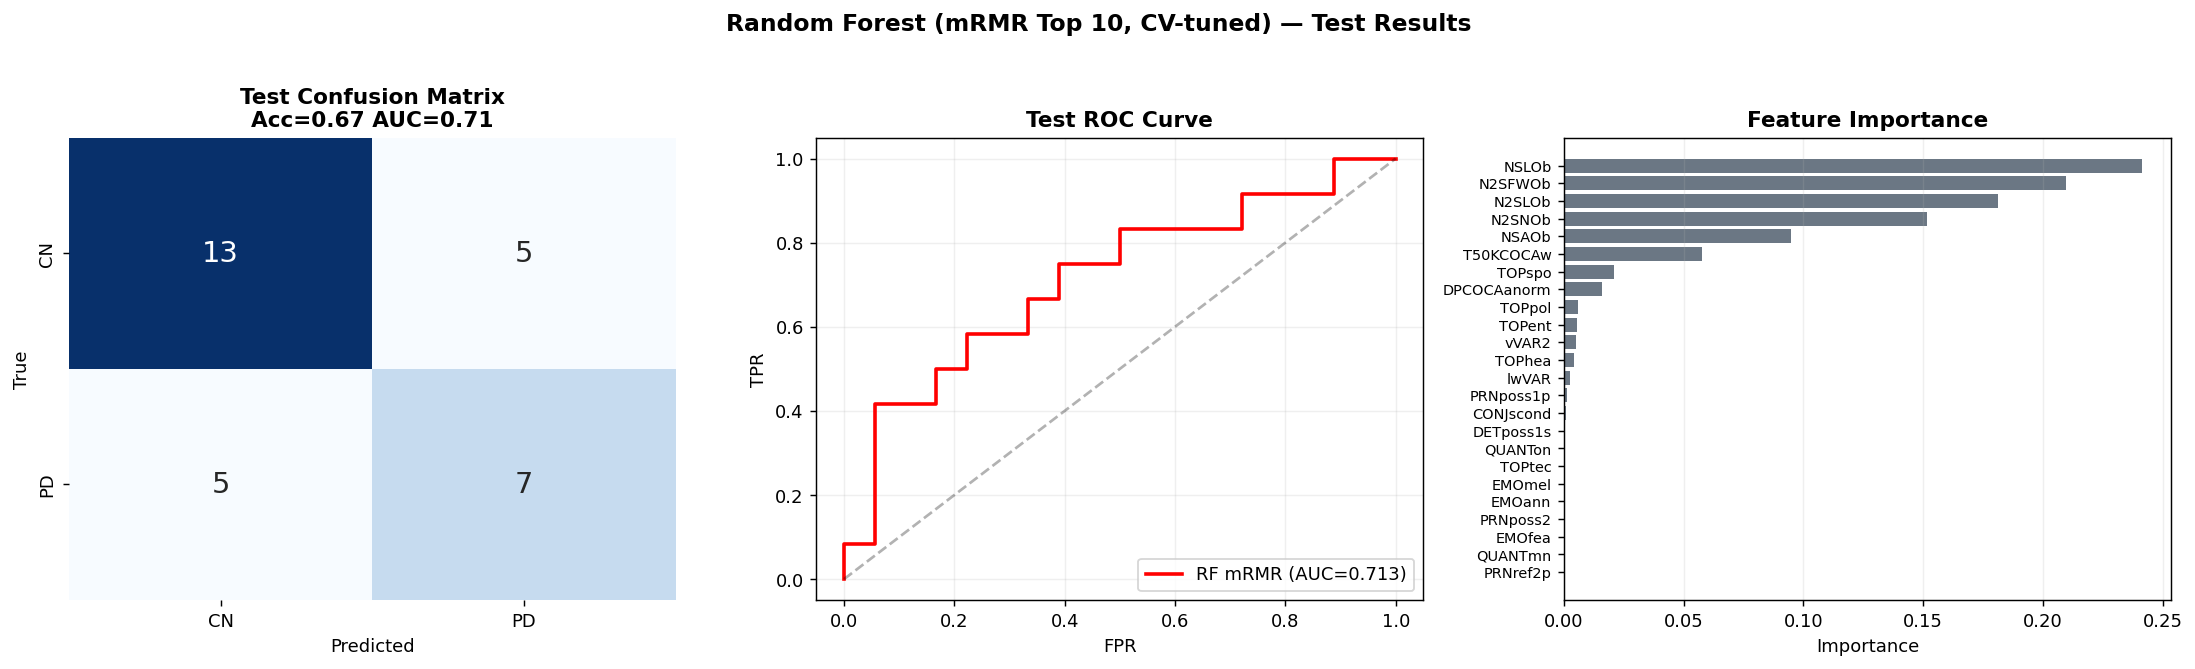

In [8]:
# ============================================================
# Visualisations
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
ax = axes[0]
cm = confusion_matrix(subj_test['true_label'], subj_test['vote_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['CN','PD'], yticklabels=['CN','PD'],
            cbar=False, annot_kws={'size':16})
ax.set_title(f'Test Confusion Matrix\nAcc={test_acc:.2f} AUC={test_auc:.2f}')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(subj_test['true_label'], subj_test['mean_prob'])
ax.plot(fpr, tpr, 'r-', linewidth=2, label=f'RF mRMR (AUC={test_auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Test ROC Curve')
ax.legend(loc='lower right'); ax.grid(alpha=0.2)

# Feature importance
ax = axes[2]
imp = final_rf.feature_importances_
idx = np.argsort(imp)[::-1]
ax.barh(range(len(features)), imp[idx], color='#2C3E50', alpha=0.7)
ax.set_yticks(range(len(features))); ax.set_yticklabels([features[i] for i in idx], fontsize=8)
ax.set_xlabel('Importance'); ax.set_title('Feature Importance')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.2)

plt.suptitle('Random Forest (mRMR Top 10, CV-tuned) — Test Results',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('rf_cv_test_results.png', dpi=150, bbox_inches='tight'); plt.show()

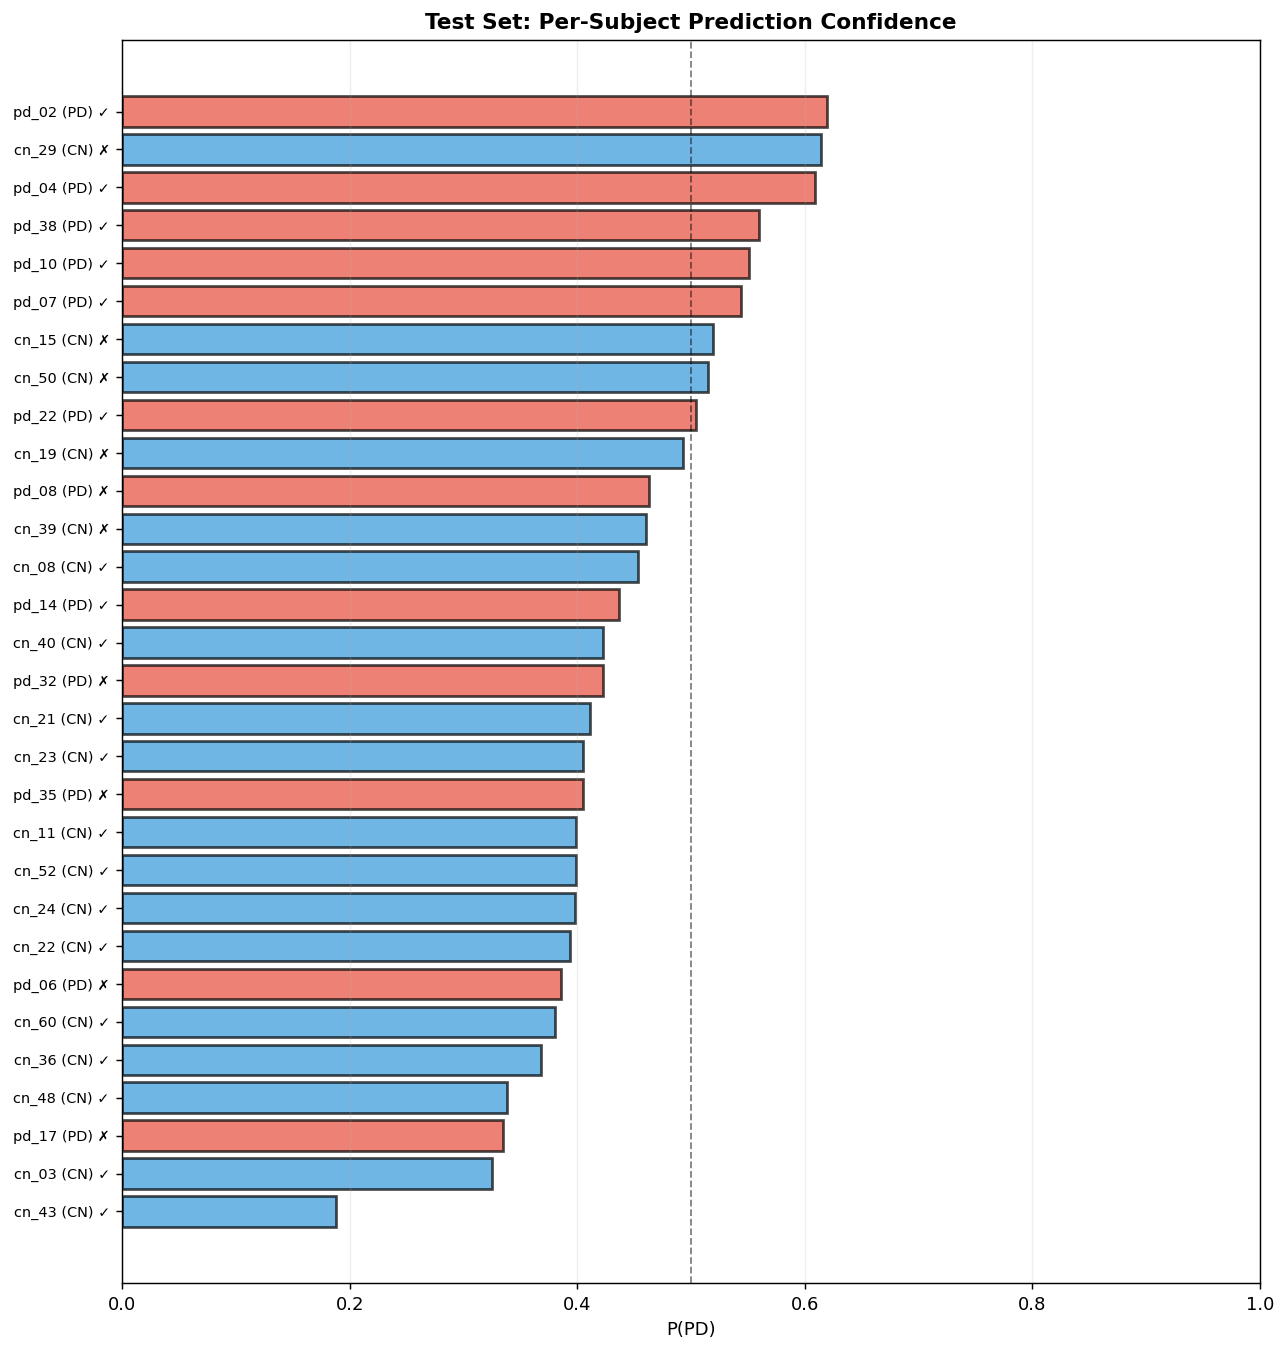

In [9]:
# ============================================================
# Per-subject confidence plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, max(4, len(subj_test)*0.35)))

subj_sorted = subj_test.sort_values('mean_prob')
colors = ['#3498DB' if r['true_label']==0 else '#E74C3C' for _, r in subj_sorted.iterrows()]
edges = ['black' if r['true_label']!=r['vote_pred'] else 'none' for _, r in subj_sorted.iterrows()]

ax.barh(range(len(subj_sorted)), subj_sorted['mean_prob'], color=colors, alpha=0.7,
        edgecolor=edges, linewidth=1.5)
ax.axvline(0.5, color='black', ls='--', lw=1, alpha=0.5)
ax.set_yticks(range(len(subj_sorted)))
ax.set_yticklabels([f"{r['subject']} ({r['group']}) {'✓' if r['true_label']==r['vote_pred'] else '✗'}"
                    for _, r in subj_sorted.iterrows()], fontsize=8)
ax.set_xlabel('P(PD)'); ax.set_xlim(0,1)
ax.set_title('Test Set: Per-Subject Prediction Confidence')
ax.grid(axis='x', alpha=0.2)

plt.tight_layout(); plt.savefig('rf_cv_confidence.png', dpi=150, bbox_inches='tight'); plt.show()

In [10]:
# ============================================================
# Summary card
# ============================================================
print('\n╔════════════════════════════════════════════════════╗')
print('║  Random Forest — mRMR Top 10 — CV-Tuned           ║')
print('╠════════════════════════════════════════════════════╣')
print(f'║  Features       : {len(features):>3d} (mRMR selected)            ║')
print(f'║  Train subjects : {len(train_subjects):>3d} (70%)                       ║')
print(f'║  Test subjects  : {len(test_subjects):>3d} (30%)                       ║')
print(f'║  CV folds       :   5 (StratifiedGroupKFold)     ║')
print(f'║  Best CV AUC    : {best_auc:.3f}                            ║')
print('╠════════════════════════════════════════════════════╣')
print(f'║  Test Accuracy  : {test_acc:.3f}                            ║')
print(f'║  Test F1        : {test_f1:.3f}                            ║')
print(f'║  Test AUC       : {test_auc:.3f}                            ║')
print(f'║  Test Sens      : {test_sens:.3f}                            ║')
print(f'║  Test Spec      : {test_spec:.3f}                            ║')
print('╠════════════════════════════════════════════════════╣')
print(f'║  Model saved    : rf_mrmr_cv.joblib               ║')
print('╚════════════════════════════════════════════════════╝')


╔════════════════════════════════════════════════════╗
║  Random Forest — mRMR Top 10 — CV-Tuned           ║
╠════════════════════════════════════════════════════╣
║  Features       :  24 (mRMR selected)            ║
║  Train subjects :  70 (70%)                       ║
║  Test subjects  :  30 (30%)                       ║
║  CV folds       :   5 (StratifiedGroupKFold)     ║
║  Best CV AUC    : 0.823                            ║
╠════════════════════════════════════════════════════╣
║  Test Accuracy  : 0.667                            ║
║  Test F1        : 0.583                            ║
║  Test AUC       : 0.713                            ║
║  Test Sens      : 0.583                            ║
║  Test Spec      : 0.722                            ║
╠════════════════════════════════════════════════════╣
║  Model saved    : rf_mrmr_cv.joblib               ║
╚════════════════════════════════════════════════════╝
